# A Practial Introduction to Sequential Monte Carlo Methods Using JAX

## Introduction

Bayesian methods are a powerful tool for statistical modeling and inference. They have become a lot more popular in recent years thanks to the increased availability of computing ressources and production-ready libraries. When it comes to sampling from posterior distributions, **Markov Chain Monte Carlo** (MCMC) is without a doubt the workhorse method. However, MCMC has a number of common failure modes. Problems typically arise when one tries to sample from very complicated posterior geometries, especially when the posterior is multimodal.

For these situations, **Sequential Monte Carlo** (SMC) methods offer an attractive alternative. While in classical MCMC, you typically have one particle exploring the posterior landscape in a random walk fashion, in SMC we generally have a whole ensemble of particles exploring the landscape together. I'd say there are three advantages to SMC, that should be considered when choosing a sampler.

First, thanks to the particle ensemble in SMC, we have a much easier time exploring the posterior. This makes SMC methods **much more likely to pick up on multimodality**, and not get stuck in a local region of high probability.

Second, SMC is **readily parallelisable**, since we are evolving all particles together. Admittedly, we can also run multiple MCMC chains in parallel, but with SMC we can parallelise the entire ensemble evolution. Think rather than having 10 particles doing 1000 steps, you have 1000 particles doing 10 steps. This can be much more efficient, provided you figure out how to properly parallelise the likelihood calculation. 

The third advantage to SMC is one that I think would make the method much more popular in scientific applications (at least in astronomy), if it was more commonly known. Namely, the SMC algorithm naturally produces an **estimate of the model evidence $Z$** along with the posterior estimate. This is a fantastic by-product if we want to compare different models.

Despite these advantages, SMC methods are not very popular for posterior estimation. (Again, I can only really speak for astronomy, where MCMC methods are a daily encounter.) I think the main reason for this is that SMC is slightly more complicated to implement, while being generally less known overall with fewer dedicated libraries. It is much easier to just pick your MCMC library of choice and not consider any alternatives. 

The goal of this post is therefore to provide a general introduction to Sequential Monte Carlo methods and how to use them in Python. We start with the nitty-gritty maths of SMC, and then demonstrates its application using BlackJAX, a modern JAX-based library for Bayesian inference in Python.

## Mathematical Background

In Bayesian inference, we want to compute the posterior distribution

$$p(\theta | y) = \frac{p(y | \theta) p(\theta)}{p(y)}$$

where
- $\theta \in \mathbb{R}^d$ are the parameters of interest
- $y$ is the observed data
- $p(y | \theta)$ is the likelihood function
- $p(\theta)$ is the prior distribution
- $p(y) = \int p(y | \theta) p(\theta) \, d\theta$ is the marginal likelihood (evidence)

The normalizing constant $p(y)$ is typically intractable, making direct sampling from the posterior impossible.

### The MCMC Approach

Typical MCMC methods construct a Markov chain $\{\theta^{(t)}\}_{t=1}^T$ whose stationary distribution is the posterior $p(\theta | y)$. Given a current state $\theta^{(t)}$, we transition to $\theta^{(t+1)}$ according to a kernel $K(\theta' | \theta)$ that satisfies:

$$\int K(\theta' | \theta) p(\theta | y) \, d\theta = p(\theta' | y)$$

This ensures that if the chain reaches the posterior distribution, it stays there. However, convergence to the stationary distribution can be slow, especially for complex posteriors.

### The Sequential Monte Carlo Approach

SMC takes a very different approach. Instead of directly targeting $p(\theta | y)$, we define a sequence (this is why its called Sequential MC) of intermediate distributions:

$$\pi_0(\theta), \pi_1(\theta), \ldots, \pi_T(\theta)$$

where:
- $\pi_0(\theta) = p(\theta)$ is the prior (easy to sample from)
- $\pi_T(\theta) = p(\theta | y)$ is the posterior (our target)
- Each $\pi_t$ is "between" the prior and posterior

We maintain a **weighted particle emsemble** $\{\theta_t^{(i)}, w_t^{(i)}\}_{i=1}^N$ that approximates each intermediate distribution:

$$\pi_t(\theta) \approx \sum_{i=1}^N w_t^{(i)} \delta_{\theta_t^{(i)}}(\theta)$$

where $\delta_{\theta}$ is a Dirac delta at $\theta$. 

Of course, the question then becomes how we construct this sequence. The most common approach to defining intermediate distributions is **likelihood tempering** (also called **annealing**). We introduce a temperature parameter $\beta_t \in [0, 1]$ and define:

$$\pi_t(\theta) \propto p(y | \theta)^{\beta_t} p(\theta)$$

where $0 = \beta_0 \leq \beta_1 \leq \cdots \leq \beta_T = 1$.

This creates a smooth path from prior to posterior. When $\beta_t = 0$, the likelihood contribution to the posterior is turned of, and we're purely sampling from the prior. Smoothly increasing $\beta_t$ increases the contribution of the likelihood until 
$\beta_T = 1$, in which case we're sampling from the target distribution (the full posterior). Since neighboring distributions $\pi_t$ and $\pi_{t+1}$ are similar, we can smoothly transition samples between them. Easing in the sampling process like this makes it easier for the algorithm to adapt to the (potentially multimodal, complex) structure of the target posterior.

We are free to choose the temperature schedule however we like. Common choices are linear $\left(\beta_t = t/T \right)$ and geometric  $\left(\beta_t =(t/T)^{\alpha} \text{ for some } \alpha > 0\right)$ schedules. Modern implemetations also often use and adaptive schedule, where $\beta_{t+1}$ is chosen based on some property of the state at time $t$. Typically, the effective sample size (ESS) is used for this (see below for a full description).

In this post, we'll use a fixed linear schedule for simplicity, though adaptive schedules are often preferred in practice. An alternative approach for construction the sequence of distributions is **data tempering**, where we gradually introduce additional observations

$$\pi_t(\theta) \propto p(y_{1:n_t} | \theta) p(\theta)$$

where $n_0 = 0 < n_1 < \cdots < n_T = N$ and $y_{1:n_t}$ denotes the first $n_t$ observations. This is the natural for online/sequential inference (e.g. for time series), where new data is added over time.

## The SMC Algorithm

The SMC algorithm consists of three main steps, repeated for $t = 1, \ldots, T$:

### 1. Reweighting

When moving from $\pi_{t-1}$ to $\pi_t$, we update particle weights using importance sampling

$$w_t^{(i)} \propto w_{t-1}^{(i)} \cdot \frac{\pi_t(\theta_{t-1}^{(i)})}{\pi_{t-1}(\theta_{t-1}^{(i)})}$$

For likelihood tempering, this simplifies to

$$w_t^{(i)} \propto w_{t-1}^{(i)} \cdot p(y | \theta_{t-1}^{(i)})^{\beta_t - \beta_{t-1}}$$

The weight update is the likelihood ratio raised to the temperature increment.

### 2. Resampling

Over time, particle weights can become degenerate (few particles carry most of the weight). We measure this using the **effective sample size (ESS)**:

$$\text{ESS}_t = \frac{1}{\sum_{i=1}^N (w_t^{(i)})^2}$$

where $w_t^{(i)}$ are normalized weights (i.e. $\sum_{i} w_t^{(i)} = 1$). The ESS ranges from 1 (complete degeneracy) to $N$ (uniform weights).

When ESS drops below a threshold (commonly $N/2$), we **resample**: draw $N$ new particles from the current weighted particle system. This eliminates low-weight particles and duplicates high-weight particles. After resampling, all weights are reset to $1/N$.

### 3. Move Step

After resampling, many particles are duplicates. To restore diversity, we apply MCMC moves that leave $\pi_t$ invariant. For each particle $\theta_t^{(i)}$, we apply $K$ steps of an MCMC kernel $K_t$ that satisfies:

$$\int K_t(\theta' | \theta) \pi_t(\theta) \, d\theta = \pi_t(\theta')$$

Common choices include Metropolis-Hastings, Hamiltonian Monte Carlo, or NUTS.

## Example: Bimodal Posterior Distribution

Let's demonstrate SMC on a 2D posterior with two well-separated modes.

In [1]:
# setup
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# JAX and BlackJAX
import jax
import jax.numpy as jnp

import blackjax
from blackjax.smc.resampling import multinomial
from blackjax.smc import extend_params

# set random key
key = jax.random.PRNGKey(1029)

# plotting setup
sns.set_style("white")
plt.rcParams["figure.figsize"] = (8, 8)

### Problem Setup

We'll create a posterior distribution with two Gaussian modes separated in 2D space:

**Prior:** 
$$p(\theta) = \mathcal{N}(\theta \mid \mathbf{0}, \sigma_p^2 \mathbf{I})$$

**Likelihood (mixture of two Gaussians):**
$$p(y | \theta) = \frac{1}{2}\mathcal{N}(\theta \mid \mu_1, \sigma_l^2 \mathbf{I}) + \frac{1}{2}\mathcal{N}(\theta \mid \mu_2, \sigma_l^2 \mathbf{I})$$

where $\mu_1 = (3, 3)$ and $\mu_2 = (-3, -3)$.

This creates a bimodal posterior that is challenging for standard MCMC.

In [2]:
def log_prior(theta: jnp.ndarray) -> jnp.ndarray:
    """Log prior: 2D Gaussian with mean 0 and std 3"""
    return jnp.array(
        jax.scipy.stats.multivariate_normal.logpdf(
            theta,
            mean=jnp.array([0.0, 0.0]),
            cov=jnp.array([[9.0, 0.0], [0.0, 9.0]]),
        )
    )


def log_likelihood(theta: jnp.ndarray) -> jnp.ndarray:
    """Log likelihood: mixture of two 2D Gaussians"""
    # Mode 1 at (3, 3)
    mode1_mean = jnp.array([3.0, 3.0])
    mode1_cov = jnp.array([[0.5, 0.0], [0.0, 0.5]])
    log_prob1 = jax.scipy.stats.multivariate_normal.logpdf(
        theta,
        mode1_mean,
        mode1_cov,
    )

    # Mode 2 at (-3, -3)
    mode2_mean = jnp.array([-3.0, -3.0])
    mode2_cov = jnp.array([[0.5, 0.0], [0.0, 0.5]])
    log_prob2 = jax.scipy.stats.multivariate_normal.logpdf(
        theta,
        mode2_mean,
        mode2_cov,
    )

    # Output is equal mixture of the two modes
    return jax.scipy.special.logsumexp(
        jnp.array([log_prob1, log_prob2]),
        b=jnp.array([0.5, 0.5]),
    )


def log_posterior(theta: jnp.ndarray) -> jnp.ndarray:
    """Unnormalized log posterior"""
    return log_prior(theta) + log_likelihood(theta)

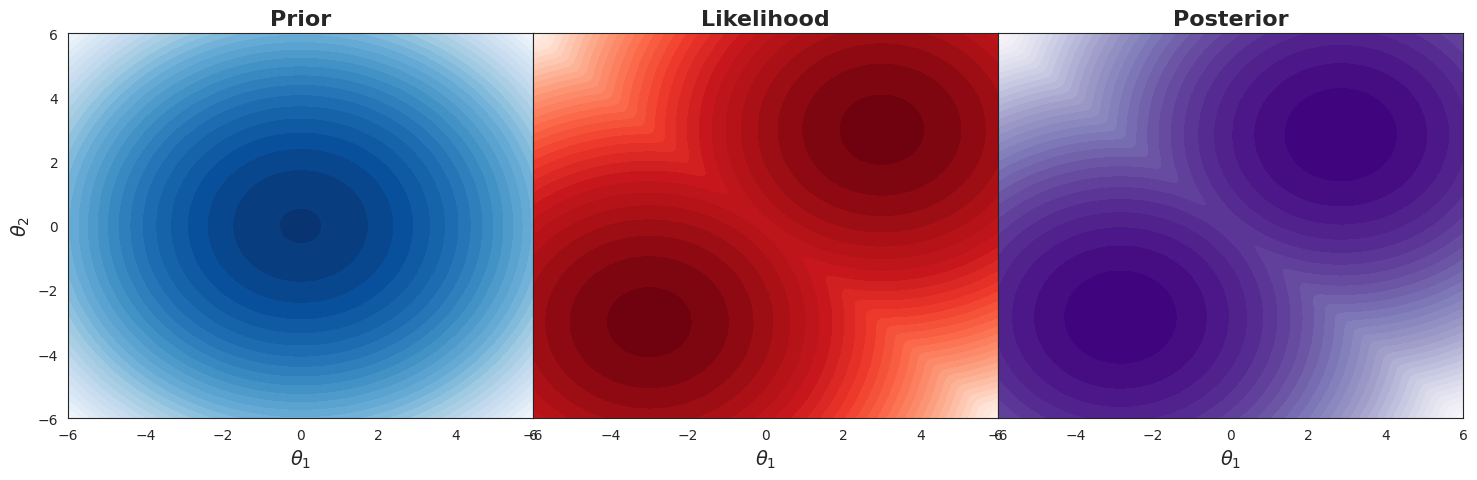

In [3]:
# calculate densities on a grid
x = np.linspace(-6, 6, 200)
y = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x, y)

Z_prior = jax.vmap(log_prior)(jnp.column_stack([X.ravel(), Y.ravel()])).reshape(X.shape)
Z_likelihood = jax.vmap(log_likelihood)(
    jnp.column_stack([X.ravel(), Y.ravel()])
).reshape(X.shape)
Z_posterior = jax.vmap(log_posterior)(jnp.column_stack([X.ravel(), Y.ravel()])).reshape(
    X.shape
)

# plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0)

titles = ["Prior", "Likelihood", "Posterior"]
cmaps = ["Blues", "Reds", "Purples"]
densities = [Z_prior, Z_likelihood, Z_posterior]

for i, (ax, Z, title, cmap) in enumerate(zip(axes, densities, titles, cmaps)):
    ax.contourf(X, Y, Z, levels=30, cmap=cmap)
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("$\\theta_1$", fontsize=14)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    if i == 0:
        ax.set_ylabel("$\\theta_2$", fontsize=14)

## Implementing SMC with BlackJAX

[BlackJAX](https://github.com/blackjax-devs/blackjax) is a fantastic library of samplers, fully implemented it JAX. It includes an implementation of tempered SMC with various options for tempering schedules, resampling schemes, and MCMC kernels.

### Setting up the SMC Sampler

We'll use BlackJAX's `tempered_smc` with with a fixed linear tempering schedule.

In [4]:
# SMC configuration
num_particles = 10000

# define fixed linear tempering schedule
num_temperatures = 50
tempering_schedule = jnp.linspace(0.0, 1.0, num_temperatures)

print(f"SMC Configuration:")
print(f"  Number of particles: {num_particles}")
print(f"  Number of temperatures: {num_temperatures}")
print(
    f"  Temperature schedule: [0.00, {tempering_schedule[1]:.3f}, ..., {tempering_schedule[-2]:.3f}, 1.00]"
)

SMC Configuration:
  Number of particles: 10000
  Number of temperatures: 50
  Temperature schedule: [0.00, 0.020, ..., 0.980, 1.00]


Now we create an initial sample of particles from the prior.

In [5]:
# initialise particles from the prior
key, init_key = jax.random.split(key)

# Sample from prior: N(0, 9I)
initial_particles = jax.random.multivariate_normal(
    init_key,
    mean=jnp.array([0.0, 0.0]),
    cov=jnp.array([[9.0, 0.0], [0.0, 9.0]]),
    shape=(num_particles,),
)

print(f"\nInitial particles shape: {initial_particles.shape}")
print(
    f"Initial particles mean: [{initial_particles.mean(axis=0)[0]:.3f}, {initial_particles.mean(axis=0)[1]:.3f}]"
)
print(
    f"Initial particles std:  [{initial_particles.std(axis=0)[0]:.3f}, {initial_particles.std(axis=0)[1]:.3f}]"
)


Initial particles shape: (10000, 2)
Initial particles mean: [-0.032, 0.016]
Initial particles std:  [3.022, 3.016]


### Running SMC

BlackJAX's `tempered_smc` function implements the full SMC algorithm. We need to provide:
- `logprior_fn`: Log prior density
- `loglikelihood_fn`: Log likelihood
- `mcmc_step_fn`: MCMC kernel that transitions a particle to a new position
- `mcmc_init_fn`: Function to initilize MCMC state
- `mcmc_parameters`: Parameters for the MCMC kernel
- `resampling_fn`: Resampling scheme
- `num_mcmc_steps`: Number of MCMC steps at each temperature

We will use the default Hamiltonian Monte Carlo sampler in BlackJAX as our MCMC algorithm.

In [6]:
# set up the HMC kernel parameters
hmc_parameters = {
    "inverse_mass_matrix": jnp.array([1.0, 1.0]),
    "num_integration_steps": 5,
    "step_size": 0.1,
}

# create HMC kernel
hmc_kernel = blackjax.hmc.build_kernel()

# create SMC kernel
smc_kernel = blackjax.tempered_smc(
    logprior_fn=log_prior,
    loglikelihood_fn=log_likelihood,
    mcmc_step_fn=hmc_kernel,  # HMC kernel for particle moves
    mcmc_init_fn=blackjax.hmc.init,  # function to initialise HMC state
    mcmc_parameters=extend_params(hmc_parameters),  # add leading dimension
    resampling_fn=multinomial,  # resample with probability proportional to weights
    num_mcmc_steps=10,  # number of MCMC steps in each SMC iteration to mix particles
)

With the MCMC kernel set up, we can create the SMC kernel, and run the SMC inference loop.

In [7]:
# define single SMC step
def one_SMC_step(carry: tuple, tempering_param: float) -> tuple:
    """Run one step of the tempered SMC algorithm using the SMC kernel for a specified tempering parameter."""
    key, state = carry
    key, step_key = jax.random.split(key)
    new_state, info = smc_kernel.step(step_key, state, tempering_param)
    return (key, new_state), (new_state, info)


# initialise SMC state
init_state = smc_kernel.init(initial_particles)

# run SMC inference loop over the tempering schedule
(_, final_sample), (history, _) = jax.lax.scan(
    one_SMC_step, (key, init_state), tempering_schedule
)

And that's it! We can look at the final sample to see if the sampling algorithm did a good job.

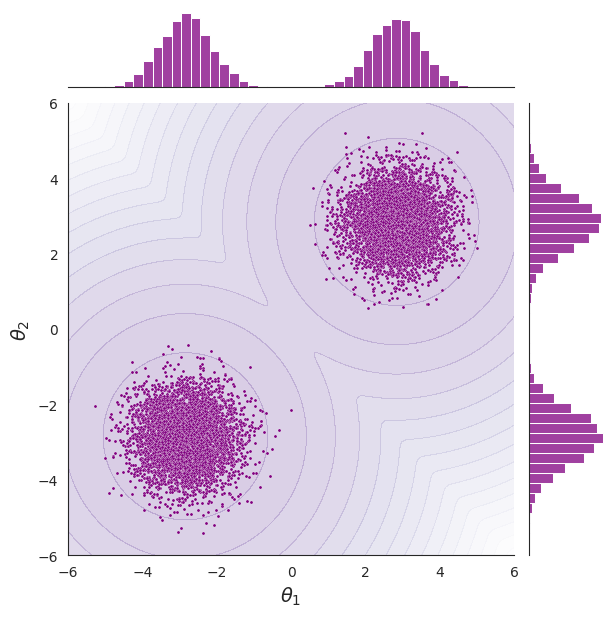

In [8]:
# plot final sample using jointplot
joint_plot = sns.jointplot(
    x=final_sample.particles[:, 0],
    y=final_sample.particles[:, 1],
    color="Purple",
    joint_kws={"s": 5},
    marginal_kws={"bins": 40},
)

# add true posterior contours
joint_plot.figure.axes[0].contourf(
    X,
    Y,
    Z_posterior,
    levels=15,
    alpha=0.2,
    zorder=-1,
    cmap="Purples",
)

joint_plot.set_axis_labels("$\\theta_1$", "$\\theta_2$", fontsize=14)

And even more fun, we can check how the particle ensemble converged towards the final distribution.

In [9]:
# get 1000 random particle indices for visualization
key, selection_key = jax.random.split(key)
indices = jax.random.choice(
    selection_key,
    num_particles,
    shape=(1000,),
    replace=False,
)


# define tempered posterior at time t for plotting
def tempered_posterior(theta: jnp.ndarray, beta: float) -> jnp.ndarray:
    """Unnormalized tempered posterior log density."""
    return log_prior(theta) + beta * log_likelihood(theta)


# create animation of the SMC process over time
fig, ax = plt.subplots(figsize=(8, 8))


def update(frame):
    ax.clear()
    particles_t = history.particles[frame, indices]
    beta_t = history.lmbda[frame]

    # Background contours
    Z_posterior_t = jax.vmap(tempered_posterior, in_axes=(0, None))(
        jnp.column_stack([X.ravel(), Y.ravel()]), beta_t
    ).reshape(X.shape)
    ax.contourf(X, Y, Z_posterior_t, levels=15, alpha=0.2, cmap="Purples")

    # Scatter plot of particles
    sc = ax.scatter(
        particles_t[:, 0],
        particles_t[:, 1],
        color="purple",
    )
    ax.set_title(f"SMC Ensemble at $\\beta$ = {beta_t:.2f}", fontsize=16)
    ax.set_xlabel("$\\theta_1$", fontsize=14)
    ax.set_ylabel("$\\theta_2$", fontsize=14)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    plt.tight_layout()
    return (sc,)


ani = FuncAnimation(fig, update, frames=num_temperatures, blit=False, interval=200)
animation_html = ani.to_jshtml()
plt.close(fig)
HTML(animation_html)

## Further Reading

- **Del Moral, Doucet, and Jasra (2006)**: "Sequential Monte Carlo samplers"
- **Zhou, Johansen, and Aston (2016)**: "An Adaptive Sequential Monte Carlo Approach"
- **Chopin and Papaspiliopoulos (2020)**: "An Introduction to Sequential Monte Carlo"



- **BlackJAX documentation**: https://blackjax-devs.github.io/blackjax/